In [1]:
from scipy.io import loadmat
import h5py


In [2]:
file_path = r'C:\Users\fkamdar\Desktop\repos\data\percept\cp_nonmotor\CPEEG02\ses-01-selected\cpeeg02_lfp_merged.mat'
with h5py.File(file_path, 'r') as f:
    print(list(f.keys()))

['#refs#', '#subsystem#', 'channel_names', 'fs_lfp', 'lfp_merged_all', 't_master', 'trig_samples_lfp', 'trig_table']


In [3]:
with h5py.File(file_path, 'r') as f:
    lfp = f['lfp_merged_all'][:].T
    t   = f['t_master'][:].squeeze()
    fs  = f['fs_lfp'][()]

print(lfp.shape)   # (channels, time)
print(t.shape)

(6, 422750)
(422750,)


In [4]:
with h5py.File(file_path, 'r') as f:
    trig_samples = f['trig_samples_lfp'][:].squeeze()

print(trig_samples[:10])

[12807. 13815. 16995. 17369. 17876. 18172. 18930. 19072. 20198. 20233.]


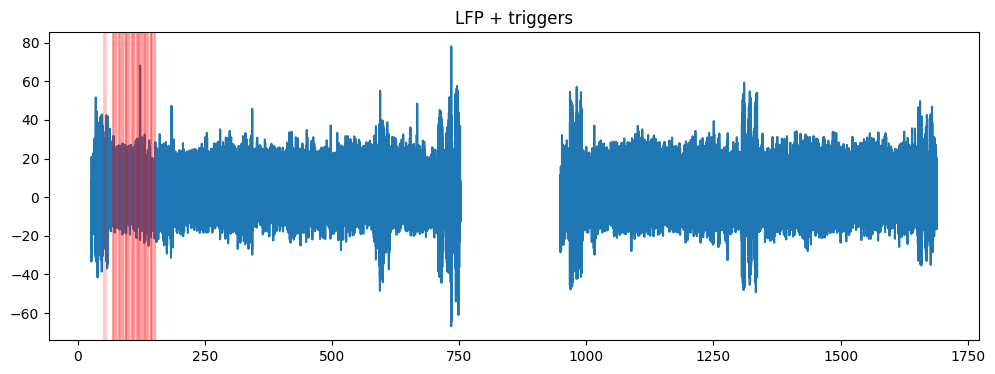

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.plot(t, lfp[0])

for s in trig_samples[:50]:  # first 50 triggers
        plt.axvline(t[int(s)], color='r', alpha=0.2)

plt.title("LFP + triggers")
plt.show()